# Feature Selection

### Large dataset → Filter  (Fast and Moderate) 
### Small dataset & high accuracy → Wrapper (Slow and High)
### Regularized models → Embedded (Medium and High)

## Method 1 : Filter Method

#### 1 - Variance threshold, 2 - Correlation coefficient, 3 - Chi-square test, 4 - ANOVA F-test, 
#### 5 - Information gain / Mutual information, 6 - Fisher score, 7 - Relief algorithm

### 1 - Variance threshold method
#### Def: that removes features whose values do not change much.
#### If a feature has very low variance, it means: it is almost constant or it does not help in prediction So, we remove it.

In [18]:
import pandas as pd

data = {
    'A': [1, 1, 1, 1, 1],        # zero variance
    'B': [2, 3, 2, 3, 2],        # low variance
    'C': [10, 20, 30, 40, 50],   # high variance
    'D': [5, 5, 5, 5, 5]         # zero variance
}

df = pd.DataFrame(data)
print(df)

   A  B   C  D
0  1  2  10  5
1  1  3  20  5
2  1  2  30  5
3  1  3  40  5
4  1  2  50  5


In [19]:
print(df.var())   # A and D have zero variance → useless features

A      0.0
B      0.3
C    250.0
D      0.0
dtype: float64


In [20]:
from sklearn.feature_selection import VarianceThreshold

VT= VarianceThreshold(threshold=0.0) # threshold = 0.0 means:Remove features with variance = 0
new = VT.fit_transform(df)

print(new)

[[ 2 10]
 [ 3 20]
 [ 2 30]
 [ 3 40]
 [ 2 50]]


In [14]:
selected_columns = df.columns[VT.get_support()]
print(selected_columns)

Index(['B', 'C'], dtype='object')


### 2 - Correlation coefficient Method: Correlation measures the strength and direction of relationship 
##### range −1 ≤ r ≤ +1 ; (a) +1=Perfect positive (b)0=No relationship (c)-1=Perfect negative
#### Keep features: Highly correlated with the target
#### Remove features:having very low correlation with target or highly correlated with each other (redundant)

In [1]:
import pandas as pd

data = {'Hours_Study': [2, 4, 6, 8, 10], 'Attendance': [60, 65, 70, 80, 90], 
        'Sleep_Hours': [8, 7, 6, 6, 5], 'Marks': [50, 55, 65, 80, 95] }

df = pd.DataFrame(data)
print(df)

   Hours_Study  Attendance  Sleep_Hours  Marks
0            2          60            8     50
1            4          65            7     55
2            6          70            6     65
3            8          80            6     80
4           10          90            5     95


In [2]:
correlation= df.corr()
print(correlation)

             Hours_Study  Attendance  Sleep_Hours     Marks
Hours_Study     1.000000    0.984798    -0.970725  0.982511
Attendance      0.984798    1.000000    -0.928655  0.998426
Sleep_Hours    -0.970725   -0.928655     1.000000 -0.924129
Marks           0.982511    0.998426    -0.924129  1.000000


#### Correlation with target = for relevance
#### Correlation between features = for redundancy removal

In [3]:
# Correlation with Target variable : Marks
# Hours_Study= 0.9825 = Very strong positive
# Attendance = 0.9984 = Extremely strong positive 
# Sleep_Hours = -0.9241 = Strong negative 

#All three features are strongly related to Marks (because |r| > 0.5)

# Multicollinearity (Feature vs Feature)

# Hours_Study = Attendance = 0.9848 (very high)
# means: Both carry almost the same information.
# In real feature selection, we keep only one of them.

In [4]:
# Step 1: Correlation with target
target_var = correlation['Marks'].drop('Marks')
target_var

Hours_Study    0.982511
Attendance     0.998426
Sleep_Hours   -0.924129
Name: Marks, dtype: float64

In [5]:
# Step 2: Remove multicollinearity
corr_features = df.drop('Marks', axis=1).corr().abs()
corr_features


,Hours_Study,Attendance,Sleep_Hours
Hours_Study,1.000000,0.984798,0.970725
Attendance,0.984798,1.000000,0.928655
Sleep_Hours,0.970725,0.928655,1.000000


In [7]:
import numpy as np
upper = correlation.where(np.triu(np.ones(correlation.shape), k=1).astype(bool))
upper

,Hours_Study,Attendance,Sleep_Hours,Marks
Hours_Study,NaN,0.984798,-0.970725,0.982511
Attendance,NaN,NaN,-0.928655,0.998426
Sleep_Hours,NaN,NaN,NaN,-0.924129
Marks,NaN,NaN,NaN,NaN


In [10]:
drop = [column for column in upper.columns if any(upper[column] > 0.9)]
drop
# We convert the correlation matrix into a form where each pair of variables is checked only once.

['Attendance', 'Marks']

In [11]:
# Final dataset
final = df.drop(columns=drop)

print("Dropped columns:", drop)
print("\nFinal Dataset:\n", final)

Dropped columns: ['Attendance', 'Marks']

Final Dataset:
    Hours_Study  Sleep_Hours
0            2            8
1            4            7
2            6            6
3            8            6
4           10            5


In [7]:
correlation = df.corr().abs()
print(correlation)

             Hours_Study  Attendance  Sleep_Hours     Marks
Hours_Study     1.000000    0.984798     0.970725  0.982511
Attendance      0.984798    1.000000     0.928655  0.998426
Sleep_Hours     0.970725    0.928655     1.000000  0.924129
Marks           0.982511    0.998426     0.924129  1.000000


In [8]:
correlation.shape

(4, 4)

In [10]:
import numpy as np
np.ones(correlation.shape)

array([[1., 1., 1., 1.],
       [1., 1., 1., 1.],
       [1., 1., 1., 1.],
       [1., 1., 1., 1.]])

In [12]:
np.triu( np.ones(correlation.shape), k=1) # k = 1 : Ignore diagonal


array([[0., 1., 1., 1.],
       [0., 0., 1., 1.],
       [0., 0., 0., 1.],
       [0., 0., 0., 0.]])

In [ ]:
.astype(bool)
.where( )

### HeatMap

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = {'Hours_Study': [2, 4, 6, 8, 10],'Attendance': [60, 65, 70, 80, 90],
    'Sleep_Hours': [8, 7, 6, 6, 5],'Marks': [50, 55, 65, 80, 95]}

df = pd.DataFrame(data)
print(df)
corr = df.corr()
print(corr)

   Hours_Study  Attendance  Sleep_Hours  Marks
0            2          60            8     50
1            4          65            7     55
2            6          70            6     65
3            8          80            6     80
4           10          90            5     95
             Hours_Study  Attendance  Sleep_Hours     Marks
Hours_Study     1.000000    0.984798    -0.970725  0.982511
Attendance      0.984798    1.000000    -0.928655  0.998426
Sleep_Hours    -0.970725   -0.928655     1.000000 -0.924129
Marks           0.982511    0.998426    -0.924129  1.000000


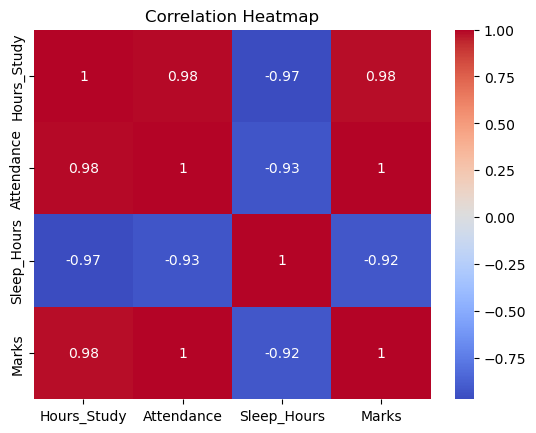

In [18]:
# Heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# 3. Chi-Square Method:
### The Chi-Square (χ²) test is a statistical technique used to select the most relevant features for a categorical target variable.
### Note: Not used for continuous target
#### Whether a feature and the target are independent or dependent: If they are dependent= important feature and If independent = not useful

#### Higher Chi-Score → More Important Feature  OR  (p-value) < 0.05 =Important feature

In [29]:
import pandas as pd

data = {'Gender': ['Male', 'Female', 'Female', 'Male', 'Female', 'Male'],
    'Education': ['UG', 'PG', 'UG', 'PG', 'UG', 'PG'],
    'Purchased': ['Yes', 'Yes', 'No', 'Yes', 'No', 'No'] }

df = pd.DataFrame(data)
print(df)

   Gender Education Purchased
0    Male        UG       Yes
1  Female        PG       Yes
2  Female        UG        No
3    Male        PG       Yes
4  Female        UG        No
5    Male        PG        No


In [30]:
from sklearn.preprocessing import LabelEncoder
LE=LabelEncoder()
df_encoded = df.apply(LE.fit_transform)
df_encoded

,Gender,Education,Purchased
0,1,1,1
1,0,0,1
2,0,1,0
3,1,0,1
4,0,1,0
5,1,0,0


In [31]:
X = df_encoded[['Gender', 'Education']]
y = df_encoded['Purchased']

In [32]:
from sklearn.feature_selection import chi2

chi_scores = chi2(X, y)
chi_scores

(array([0.33333333, 0.33333333]), array([0.56370286, 0.56370286]))

In [33]:
import pandas as pd

chi_values = pd.DataFrame({'Feature': X.columns,'Chi_Score': chi_scores[0],
                           'p_value': chi_scores[1] })

print(chi_values) 

     Feature  Chi_Score   p_value
0     Gender   0.333333  0.563703
1  Education   0.333333  0.563703


#### Using selectKBest

In [34]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, chi2

data = {'Gender': ['Male', 'Female', 'Female', 'Male', 'Female', 'Male'],
    'Education': ['UG', 'PG', 'UG', 'PG', 'UG', 'PG'],
    'Purchased': ['Yes', 'Yes', 'No', 'Yes', 'No', 'No']}

df = pd.DataFrame(data)
print(df)
df_encoded = df.apply(LabelEncoder().fit_transform)
print(df_encoded)

X = df_encoded[['Gender', 'Education']]
y = df_encoded['Purchased']


   Gender Education Purchased
0    Male        UG       Yes
1  Female        PG       Yes
2  Female        UG        No
3    Male        PG       Yes
4  Female        UG        No
5    Male        PG        No
   Gender  Education  Purchased
0       1          1          1
1       0          0          1
2       0          1          0
3       1          0          1
4       0          1          0
5       1          0          0


In [36]:
selector = SelectKBest(score_func=chi2, k=1)
print(selector)
X_new = selector.fit_transform(X, y)
print(X_new)

SelectKBest(k=1, score_func=<function chi2 at 0x00000198C9BEDDA0>)
[[1]
 [0]
 [1]
 [0]
 [1]
 [0]]


In [39]:
scores = pd.DataFrame({'Feature': X.columns,'Chi_Score': selector.scores_,
                       'p_value': selector.pvalues_})
print(scores)

print("\nSelected Feature:", X.columns[selector.get_support()])

     Feature  Chi_Score   p_value
0     Gender   0.333333  0.563703
1  Education   0.333333  0.563703

Selected Feature: Index(['Education'], dtype='object')


# 4 - ANOVA F-test
### Apply = Does a numerical feature significantly affect a categorical target?

#### In feature selection: It tells us which numerical feature is important for classification

#### When to Use: Input (X) → Numerical and Target (y) → Categorical

#### ANOVA use for the Variance between the group or within the group
#### F value = Between/within : Higher F-value = More important feature

In [1]:
import pandas as pd

data = {'Study_Hours': [2, 3, 5, 6, 8, 9],'Sleep_Hours': [8, 7, 7, 6, 5, 5],
    'Pass': ['No', 'No', 'Yes', 'Yes', 'Yes', 'Yes']}

df = pd.DataFrame(data)
print(df)

   Study_Hours  Sleep_Hours Pass
0            2            8   No
1            3            7   No
2            5            7  Yes
3            6            6  Yes
4            8            5  Yes
5            9            5  Yes


In [2]:
from sklearn.preprocessing import LabelEncoder

X = df[['Study_Hours', 'Sleep_Hours']]
y = LabelEncoder().fit_transform(df['Pass'])

In [15]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X, y)


SelectKBest(k='all')

In [16]:
scores = pd.DataFrame({'Feature': X.columns,'F_Score': selector.scores_,
                       'p_value': selector.pvalues_})
print(scores)

       Feature    F_Score   p_value
0  Study_Hours  10.285714  0.032678
1  Sleep_Hours   5.025641  0.088446


In [8]:
selector = SelectKBest(score_func=f_classif, k=1)
X_new = selector.fit_transform(X, y)
print("Selected Feature:", X.columns[selector.get_support()])

Selected Feature: Index(['Study_Hours'], dtype='object')


# 5 - Information gain / Mutual information

### How much information a feature gives about the target (Does this feature help reduce uncertainty about the output?)

#### Information Gain = Entropy(before) – Entropy(after split)  "If uncertainty reduces a lot =  Important feature"
#### Higher MI score = More important feature

#### Entropy = Impurity or randomness

#### When to Use: Input (X) → Categorical OR Numerical and Target (y) → Categorical


In [21]:
import pandas as pd

data= {'Study_Hours':[2, 3, 5, 6, 8, 9],
       'Attendance': [60, 65, 70, 75, 80, 90],
    'Pass': ['No', 'No', 'Yes', 'Yes', 'Yes', 'Yes']}

df = pd.DataFrame(data)
print(df)

   Study_Hours  Attendance Pass
0            2          60   No
1            3          65   No
2            5          70  Yes
3            6          75  Yes
4            8          80  Yes
5            9          90  Yes


In [22]:
from sklearn.preprocessing import LabelEncoder

X = df[['Study_Hours', 'Attendance']]
y = LabelEncoder().fit_transform(df['Pass'])

In [23]:
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(X, y)
mi

array([0.67222222, 0.35555556])

In [24]:
result = pd.DataFrame({'Feature': X.columns,'MI_Score': mi})
print(result)   

       Feature  MI_Score
0  Study_Hours  0.672222
1   Attendance  0.355556


In [25]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

selector = SelectKBest(score_func=mutual_info_classif, k=1)
X_new = selector.fit_transform(X, y)

print("Selected MI Feature:", X.columns[selector.get_support()])

Selected MI Feature: Index(['Study_Hours'], dtype='object')


# 6 - Fisher score
#### Fisher Score is another filter-based feature selection technique commonly used in classification problems. It is closely related to the idea used in ANOVA. 

#### The Fisher Score measures how well a feature separates different classes.
#### A good feature should: Have large distance between class means (classes far apart), Have small variance within each class. So the feature clearly distinguishes classes.

#### Fisher Score=Between-class variance/  Within-class variance
#### Where, Between-class variance → difference between class means & Within-class variance → spread inside each class
#### If classes are well separated, the Fisher score becomes high.
#### Higher Fisher Score → better class separation

In [3]:
import pandas as pd

data = {'Study_Hours':[2,3,4,7,8,9],'Attendance':[60,65,70,85,90,95],
    'Sleep_Hours':[8,7,6,6,5,5],'Pass':[0,0,0,1,1,1]}

df = pd.DataFrame(data)
print(df)

   Study_Hours  Attendance  Sleep_Hours  Pass
0            2          60            8     0
1            3          65            7     0
2            4          70            6     0
3            7          85            6     1
4            8          90            5     1
5            9          95            5     1


In [6]:
import numpy as np

X = df[['Study_Hours','Attendance','Sleep_Hours']]
y = df['Pass']

fisher_scores = {}

for feature in X.columns:
    
    mean_overall = X[feature].mean()
    
    score_num = 0
    score_den = 0
    
    for c in np.unique(y):
        
        Xi = X[feature][y==c]
        mean_class = Xi.mean()
        var_class = Xi.var()
        
        score_num += len(Xi)*(mean_class-mean_overall)**2
        score_den += len(Xi)*var_class
        
    fisher_scores[feature] = score_num/score_den

print(fisher_scores)

{'Study_Hours': 6.25, 'Attendance': 6.25, 'Sleep_Hours': 1.041666666666667}


In [4]:
import pandas as pd

data = {'Study_Hours':[2,3,4,7,8,9],'Attendance':[60,65,70,85,90,95],
    'Sleep_Hours':[8,7,6,6,5,5],'Pass':[0,0,0,1,1,1]}

df = pd.DataFrame(data)
print(df)

X = df[['Study_Hours','Attendance','Sleep_Hours']]
y = df['Pass']

   Study_Hours  Attendance  Sleep_Hours  Pass
0            2          60            8     0
1            3          65            7     0
2            4          70            6     0
3            7          85            6     1
4            8          90            5     1
5            9          95            5     1


In [5]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

selector = SelectKBest(score_func=f_classif, k='all')

selector.fit(X, y)

scores = selector.scores_

result = pd.DataFrame({"Feature": X.columns,"Fisher_Score": scores})

print(result)

       Feature  Fisher_Score
0  Study_Hours         37.50
1   Attendance         37.50
2  Sleep_Hours          6.25


In [7]:
selector = SelectKBest(score_func=f_classif, k=1)

X_new = selector.fit_transform(X, y)

print("Selected Feature:")
print(X.columns[selector.get_support()])

Selected Feature:
Index(['Attendance'], dtype='object')


##  7 - Relief algorithm
Relief selects features by comparing each data point with: Nearest instance from the same class → Nearest Hit
Nearest instance from a different class → Nearest Miss Then it updates a feature weight.

#### A good feature should: Have similar values for same-class instances & Have different values for different-class instances
#### So the feature that separates classes well receives a higher score.

#### Randomly pick an instance 𝑅
#### Find: Nearest Hit (H) → same class, Nearest Miss (M) → different class
#### Update feature weights:W[A]=W[A]−diff(R,H)+diff(R,M)
##### Where: diff(R,H) → difference between instance and nearest hit
##### diff(R,M) → difference between instance and nearest miss
#### Repeat for multiple samples.

In [9]:
!pip install skrebate 

In [11]:
import pandas as pd

data = {'Study_Hours':[2,3,4,7,8,9],'Attendance':[60,65,70,85,90,95],
    'Sleep_Hours':[8,7,6,6,5,5],'Pass':[0,0,0,1,1,1]}

df = pd.DataFrame(data)

X = df[['Study_Hours','Attendance','Sleep_Hours']]
y = df['Pass']

In [12]:
from skrebate import ReliefF

relief = ReliefF(n_neighbors=2)

relief.fit(X.values, y.values)

scores = relief.feature_importances_

result = pd.DataFrame({"Feature": X.columns,"Relief_Score": scores})

print(result)

       Feature  Relief_Score
0  Study_Hours           0.0
1   Attendance           0.0
2  Sleep_Hours           0.0


In [ ]:
Method | Feature Type(input Var) | Target Type (output Var)

Correlation| Numerical | Numerical
Chi-Square | Categorical | Categorical
ANOVA | Numerical |Categorical
IG or MI | Categorical or Numerical | Categorical
Fisher Score | Numerical | Categorical and problem(Classification)

Relif Algorithm | Numerical or categorical | Categorical {Problem	Classification and Strength	Detects feature interactions}

## Filter methods = select features before model training
## Wrapper methods = select features using model performance

### Process: Dataset → Feature Selection → Model Training
### Filter method:Correlation → Select features → Train model
### Wrapper method:Train model → Evaluate feature subset → Select best subset

# Method 2 Wrapper Method

### Wrapper methods select features by training a machine learning model repeatedly and evaluating its performance.
### Instead of using statistical tests, it “wraps” the feature selection process around a model.

### There are three main wrapper methods:
#### Forward Selection = Start with no features, add best features
#### Backward Elimination = Start with all features, remove worst
#### Recursive Feature Elimination (RFE) = Iteratively remove least important features

# Forward Selection: 
### Start with zero features and add features one by one. Selects the combination which give highest accuracy
#### Steps: 
### Train model with each single feature
### Select feature with highest accuracy
### Add next best feature
### Repeat until no improvement


In [9]:
import pandas as pd

data = {'Study_Hours':[2,3,4,7,8,9],'Attendance':[60,65,70,85,90,95],
    'Sleep_Hours':[8,7,6,6,5,5],'Pass':[0,0,0,1,1,1]}

df = pd.DataFrame(data)

X = df[['Study_Hours','Attendance','Sleep_Hours']]
y = df['Pass']

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SequentialFeatureSelector

model = LogisticRegression()

sfs = SequentialFeatureSelector(model,n_features_to_select=2,
                                direction='forward',cv=3)

sfs.fit(X, y)

selected = X.columns[sfs.get_support()]

print("Selected Features:", selected)

Selected Features: Index(['Study_Hours', 'Attendance'], dtype='object')


# Backward Selection: 
### Start with all features and remove the least useful feature.
#### Steps: 
### Train model using all features
### Remove feature with lowest importance
### Retrain model
### Repeat until performance drops

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SequentialFeatureSelector

model = LogisticRegression()

sfs = SequentialFeatureSelector(model,n_features_to_select=2,
                                direction='backward',cv=3)

sfs.fit(X, y)

selected_features = X.columns[sfs.get_support()]

print("Selected Features:", selected_features)

Selected Features: Index(['Attendance', 'Sleep_Hours'], dtype='object')


# Recursive Feature Elimination (RFE)
### RFE repeatedly:
### Trains a model
### Ranks features by importance
### Removes the least important feature
### Repeats until desired number of features remains
### This method is implemented in scikit-learn.

In [13]:
import pandas as pd

data = {'Hours_Study': [2,4,6,8,10,3,7,9],'Attendance': [60,65,70,80,90,75,85,95],
    'Sleep_Hours': [8,7,6,6,5,7,6,5],'Practice_Test': [1,2,3,4,5,2,4,5],
        'Marks': [50,55,65,80,95,60,85,90]}

df = pd.DataFrame(data)

X = df[['Hours_Study','Attendance','Sleep_Hours','Practice_Test']]
y = df['Marks']

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE

model = LinearRegression()

rfe = RFE(model, n_features_to_select=2)

rfe.fit(X, y)

print("Selected Features:", X.columns[rfe.support_])
print("Feature Ranking:", rfe.ranking_)

Selected Features: Index(['Sleep_Hours', 'Practice_Test'], dtype='object')
Feature Ranking: [2 3 1 1]


# Embedded Method
### The Embedded Method is a feature selection technique where the model itself selects the important features during training.

### During model training:
#### Model learns patterns from data
#### It assigns importance / weights to features
#### Less important features automatically get small or zero weights
#### Important features are selected

In [ ]:
import pandas as pd

data = {'Hours_Study': [2,4,6,8,10,3,7,9],'Attendance': [60,65,70,80,90,75,85,95],
    'Sleep_Hours': [8,7,6,6,5,7,6,5],'Practice_Test': [1,2,3,4,5,2,4,5],
        'Marks': [50,55,65,80,95,60,85,90]}

df = pd.DataFrame(data)

X = df[['Hours_Study','Attendance','Sleep_Hours','Practice_Test']]
y = df['Marks']

In [15]:
from sklearn.linear_model import Lasso

model = Lasso(alpha=0.1)

model.fit(X, y)

importance = model.coef_

print("Feature Importance:", importance)

Feature Importance: [4.24843443 0.80167327 4.58195445 0.        ]


In [16]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()

model.fit(X, y)

importance = model.feature_importances_

print("Feature Importance:", importance)

Feature Importance: [0.32565843 0.29266749 0.13347642 0.24819766]
